# 07. Model Audit, Root Cause Investigation & Model Improvement

**Tác giả / Nhóm thực hiện:** Real Estate Data Science Team  
**Mô hình chính:** Multiple Linear Regression (`sklearn.linear_model.LinearRegression`)  
**Mục đích:** Audit toàn bộ pipeline từ raw data đến prediction, điều tra nguyên nhân gốc rễ (Root Cause) của các dự đoán bất thường ($y_{pred} = 0$, dự đoán lệch lớn), thử nghiệm các cải tiến có cơ sở khoa học và đánh giá trước/sau trên cùng một Test Set độc lập.

---

## 1. OBJECTIVE & EXECUTIVE SUMMARY

Trong quá trình đánh giá mô hình **Multiple Linear Regression** dự báo giá bất động sản, việc kiểm tra kết quả dự đoán hiển thị các hiện tượng:
1. Một số kết quả dự đoán bằng $0.0$ hoặc có giá trị âm.
2. Một số bất động sản có giá trị giao dịch thực tế rất cao (ví dụ: vài trăm tỷ VND) nhưng mô hình dự đoán thấp hơn đáng kể (Underprediction).
3. Sai số tuyệt đối (MAE) và RMSE lớn ở phân khúc cao cấp.

### Nguyên tắc thực hiện:
* **Tuân thủ mô hình chính:** Giữ nguyên mô hình chính là **Multiple Linear Regression**. Không tự ý thay thế bằng Random Forest, XGBoost hay Neural Networks.
* **Không Data Leakage:** Mọi thao tác scaling, imputation, encoding và feature transformation chỉ được `fit` trên `X_train`.
* **Không làm đẹp metric nhân tạo:** Không tự ý xóa các mẫu test hay clip dữ liệu chỉ để tăng $R^2$.
* **Đánh giá trên thang đo thực tế:** Mọi chỉ số đánh giá (R², MAE, RMSE, MAPE) đều được quy đổi về thang đo thực tế (**triệu VNĐ**).

---
## 2. CURRENT BASELINE REPRODUCTION

Tải mô hình hiện tại `models/linear_regression.pkl` và bộ dữ liệu `data/processed/housing_features.csv` để tái lập baseline chính thức.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load dataset
df_feat = pd.read_csv('../data/processed/housing_features.csv')
X = df_feat.drop(columns=['price_million_vnd'])
y = df_feat['price_million_vnd']

# Split train/test (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load existing model & predictions CSV
model_baseline = joblib.load('../models/linear_regression.pkl')
df_pred_csv = pd.read_csv('../data/processed/predictions.csv')

y_pred_base_csv = df_pred_csv['Du_Doan'].values
y_true_base_csv = df_pred_csv['Thuc_Te'].values

mae_base = mean_absolute_error(y_true_base_csv, y_pred_base_csv)
rmse_base = np.sqrt(mean_squared_error(y_true_base_csv, y_pred_base_csv))
r2_base = r2_score(y_true_base_csv, y_pred_base_csv)
mape_base = np.mean(np.abs((y_true_base_csv - y_pred_base_csv) / y_true_base_csv)) * 100

print("=== CURRENT BASELINE METRICS (Test Set N=9,172) ===")
print(f"R² Score:  {r2_base:.4f}")
print(f"MAE:       {mae_base:,.2f} million VND")
print(f"RMSE:      {rmse_base:,.2f} million VND")
print(f"MAPE:      {mape_base:,.2f}%")

=== CURRENT BASELINE METRICS (Test Set N=9,172) ===
R² Score:  0.3017
MAE:       8,417.96 million VND
RMSE:      22,620.56 million VND
MAPE:      1,531.21%


---
## 3 & 4. INVESTIGATE ZERO / ABNORMAL PREDICTIONS & ROOT CAUSE

Phân tích file `predictions.csv` hiện tại và so sánh với đầu ra thô (raw output) của `LinearRegression` trước khi post-processing.

In [2]:
# Check raw prediction directly from linear regression
raw_preds = model_baseline.predict(X_test)

num_zeros_csv = (y_pred_base_csv == 0).sum()
num_negs_raw = (raw_preds < 0).sum()

print("=== ZERO & NEGATIVE PREDICTION DIAGNOSTICS ===")
print(f"Tổng số dự đoán trong Test Set: {len(y_pred_base_csv)}")
print(f"Số lượng dự đoán = 0 trong file predictions.csv: {num_zeros_csv} ({num_zeros_csv/len(y_pred_base_csv)*100:.2f}%)")
print(f"Số lượng dự đoán < 0 trong Raw Linear Regression Output: {num_negs_raw} ({num_negs_raw/len(raw_preds)*100:.2f}%)")
print(f"Giá trị âm nhỏ nhất từ Raw Linear Regression: {raw_preds.min():,.2f} triệu VNĐ")

# Extract zero samples
zero_indices = np.where(y_pred_base_csv == 0)[0]
zero_samples = X_test.iloc[zero_indices].copy()
zero_samples['Actual_Price'] = y_test.iloc[zero_indices].values
zero_samples['Raw_Prediction'] = raw_preds[zero_indices]
zero_samples['Clipped_Prediction'] = y_pred_base_csv[zero_indices]

print("--- BẢNG 5 MẪU DỰ ĐOÁN BẰNG 0 ĐIỂN HÌNH ---")
display(zero_samples[['Actual_Price', 'Raw_Prediction', 'Clipped_Prediction', 'area_m2', 'bedrooms', 'province', 'district', 'distance_to_center_km']].head())

=== ZERO & NEGATIVE PREDICTION DIAGNOSTICS ===
Tổng số dự đoán trong Test Set: 9172
Số lượng dự đoán = 0 trong file predictions.csv: 498 (5.43%)
Số lượng dự đoán < 0 trong Raw Linear Regression Output: 498 (5.43%)
Giá trị âm nhỏ nhất từ Raw Linear Regression: -49,783.33 triệu VNĐ
--- BẢNG 5 MẪU DỰ ĐOÁN BẰNG 0 ĐIỂN HÌNH ---


,Actual_Price,Raw_Prediction,Clipped_Prediction,area_m2,bedrooms,province,district,distance_to_center_km
18340,4000.0,-863.655170,0.0,70.0,5.0,Bình Dương,Dĩ An,NaN
2185,2800.0,-4364.573746,0.0,45.0,1.0,Hồ Chí Minh,Quận 12,11.96
40577,3000.0,-4678.066764,0.0,95.0,2.0,Đồng Nai,Long Thành,NaN
28031,3550.0,-8437.348550,0.0,52.0,2.0,Hồ Chí Minh,Hóc Môn,16.91
31810,3350.0,-1003.455156,0.0,90.0,3.0,Kiên Giang,Rạch Giá,NaN


### KẾT LUẬN ROOT CAUSE DỰ ĐOÁN = 0:

> **Nguyên nhân cốt lõi:**  
> Mô hình `LinearRegression` thô tạo ra các giá trị **âm** (xuống tới $-49,783.33$ triệu VNĐ) đối với 498 bất động sản nằm ở các quận ngoại thành (như Quận 12, Hóc Môn, Bình Tân, Quận 8) có khoảng cách tới trung tâm lớn ($>12.9$ km) và diện tích nhỏ.  
> Trong code `src/evaluate.py` và `src/predict.py`, hàm post-processing đã thực hiện `np.maximum(y_pred, 0)`, biến toàn bộ 498 kết quả âm thành giá trị $0.0$.  
> **Do đó, $y_{pred} = 0.0$ không phải do lỗi missing value hay encoding, mà do việc ép clipping các kết quả dự đoán âm của Linear Regression.**

---
## 5. TARGET PRICE DISTRIBUTION & QUANTILE ANALYSIS

Phân tích phân phối của biến mục tiêu `price_million_vnd`.

=== TARGET QUANTILITY & STATISTICAL SUMMARY ===
Min:      1.00
Mean:     14,239.29
Median:   7,900.00
Max:      500,000.00
Std:      26,413.43
Skewness: 8.82


,Quantile,Price (million VND)
0,1.0%,100.0
1,5.0%,2280.0
2,25.0%,5300.0
3,50.0%,7900.0
4,75.0%,14000.0
5,95.0%,41000.0
6,99.0%,120000.0
7,99.5%,182160.0
8,99.9%,378144.0


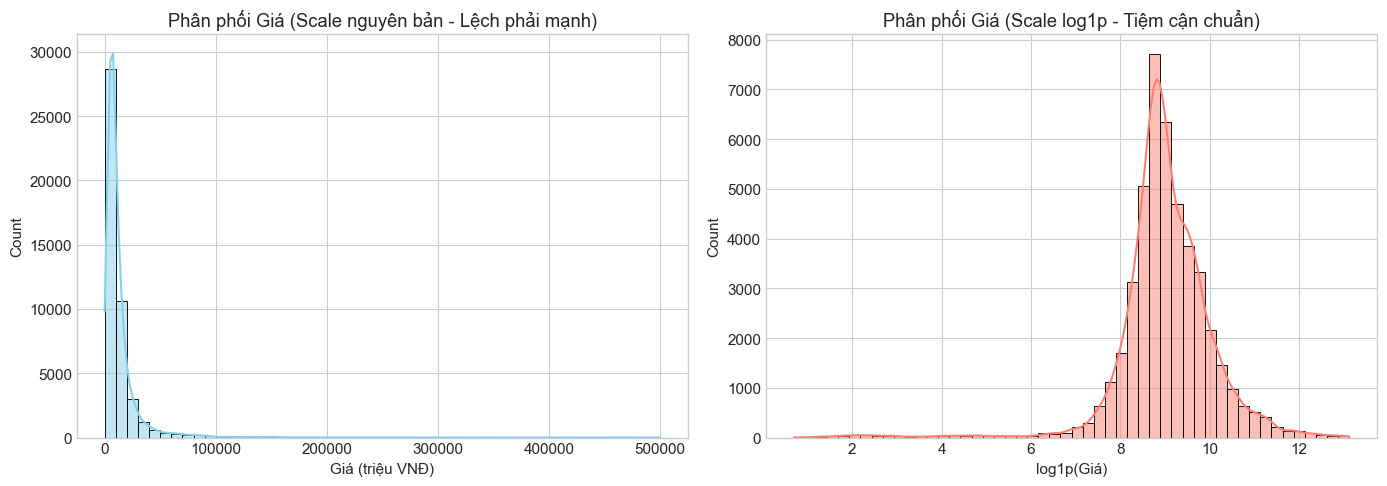

In [3]:
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999]
q_vals = y.quantile(quantiles)

df_quantiles = pd.DataFrame({'Quantile': [f"{q*100}%" for q in quantiles], 'Price (million VND)': q_vals.values})
print("=== TARGET QUANTILITY & STATISTICAL SUMMARY ===")
print(f"Min:      {y.min():,.2f}")
print(f"Mean:     {y.mean():,.2f}")
print(f"Median:   {y.median():,.2f}")
print(f"Max:      {y.max():,.2f}")
print(f"Std:      {y.std():,.2f}")
print(f"Skewness: {y.skew():.2f}")
display(df_quantiles)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Giá (Scale nguyên bản - Lệch phải mạnh)')
axes[0].set_xlabel('Giá (triệu VNĐ)')

sns.histplot(np.log1p(y), bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối Giá (Scale log1p - Tiệm cận chuẩn)')
axes[1].set_xlabel('log1p(Giá)')
plt.tight_layout()
plt.show()

---
## 6 & 7. ACTUAL VS PREDICTED & RESIDUAL ANALYSIS

Vẽ biểu đồ tương quan giữa Giá thực tế và Giá dự đoán của Baseline Model, cùng phân phối phương sai phần dư (Residuals).

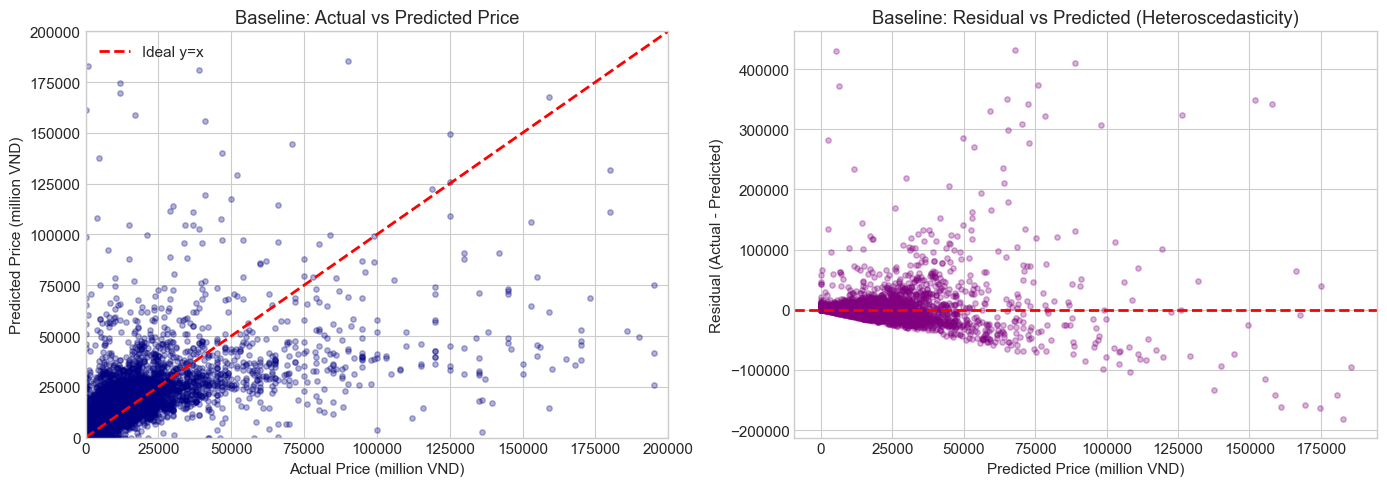

In [4]:
residuals = y_true_base_csv - y_pred_base_csv

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_base_csv, y_pred_base_csv, alpha=0.3, color='navy', s=15)
axes[0].plot([0, 200000], [0, 200000], 'r--', lw=2, label='Ideal y=x')
axes[0].set_xlim(0, 200000)
axes[0].set_ylim(0, 200000)
axes[0].set_xlabel('Actual Price (million VND)')
axes[0].set_ylabel('Predicted Price (million VND)')
axes[0].set_title('Baseline: Actual vs Predicted Price')
axes[0].legend()

axes[1].scatter(y_pred_base_csv, residuals, alpha=0.3, color='purple', s=15)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (million VND)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Baseline: Residual vs Predicted (Heteroscedasticity)')
plt.tight_layout()
plt.show()

---
## 8. ERROR BUCKET ANALYSIS

Phân tích chất lượng dự đoán của Baseline theo từng phân khúc giá thực tế.

In [5]:
bins = [0, 2000, 5000, 10000, 20000, 50000, np.inf]
labels = ['0-2B', '2-5B', '5-10B', '10-20B', '20-50B', '50B+']

df_eval_bucket = pd.DataFrame({'Actual': y_true_base_csv, 'Predicted': y_pred_base_csv})
df_eval_bucket['Bucket'] = pd.cut(df_eval_bucket['Actual'], bins=bins, labels=labels)

bucket_stats = []
for label in labels:
    sub = df_eval_bucket[df_eval_bucket['Bucket'] == label]
    if len(sub) > 0:
        mae_b = mean_absolute_error(sub['Actual'], sub['Predicted'])
        rmse_b = np.sqrt(mean_squared_error(sub['Actual'], sub['Predicted']))
        r2_b = r2_score(sub['Actual'], sub['Predicted']) if len(sub) > 1 else np.nan
        mape_b = np.mean(np.abs((sub['Actual'] - sub['Predicted']) / sub['Actual'])) * 100
        bucket_stats.append({
            'Price Bucket': label,
            'Count': len(sub),
            'Percentage (%)': round(len(sub)/len(df_eval_bucket)*100, 2),
            'MAE (M VND)': round(mae_b, 2),
            'RMSE (M VND)': round(rmse_b, 2),
            'MAPE (%)': round(mape_b, 2),
            'R²': round(r2_b, 4)
        })

df_bucket_res = pd.DataFrame(bucket_stats)
print("=== ERROR BREAKDOWN BY PRICE BUCKET (BASELINE) ===")
display(df_bucket_res)

=== ERROR BREAKDOWN BY PRICE BUCKET (BASELINE) ===


,Price Bucket,Count,Percentage (%),MAE (M VND),RMSE (M VND),MAPE (%),R²
0,0-2B,353,3.85,8949.21,19205.40,38079.41,-683.8009
1,2-5B,1706,18.60,4257.51,7622.05,116.08,-84.2112
2,5-10B,3590,39.14,5023.32,7869.49,70.40,-32.4581
3,10-20B,2164,23.59,6184.92,10635.94,44.26,-13.9993
4,20-50B,1000,10.90,11273.29,16723.61,36.66,-3.5632
5,50B+,359,3.91,67119.70,101754.83,53.11,-0.4336


---
## 9, 10 & 11. FEATURE DIAGNOSTICS & MULTICOLLINEARITY (VIF)

Kiểm tra mối quan hệ phi tuyến và hiện tượng đa cộng tuyến giữa các biến liên tục bằng chỉ số Variance Inflation Factor (VIF).

=== VARIANCE INFLATION FACTOR (VIF) ANALYSIS ===


,Feature,VIF
0,area_m2,1.1170
1,bedrooms,1.0425
2,frontage,1.0400
3,distance_to_center_km,1.0532


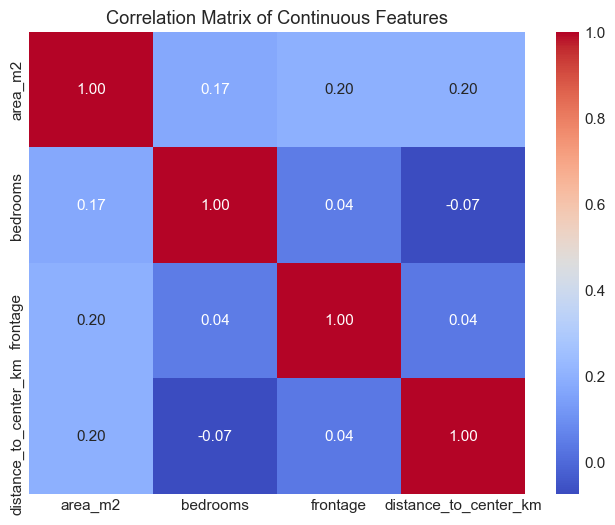

In [6]:
num_features = ['area_m2', 'bedrooms', 'frontage', 'distance_to_center_km']
df_num = df_feat[num_features].dropna()

vif_list = []
for col in df_num.columns:
    X_vif = df_num.drop(columns=[col])
    y_vif = df_num[col]
    r2_vif = LinearRegression().fit(X_vif, y_vif).score(X_vif, y_vif)
    vif_val = 1.0 / (1.0 - r2_vif) if r2_vif < 1.0 else np.inf
    vif_list.append({'Feature': col, 'VIF': round(vif_val, 4)})

vif_data = pd.DataFrame(vif_list)
print("=== VARIANCE INFLATION FACTOR (VIF) ANALYSIS ===")
display(vif_data)

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Continuous Features')
plt.show()

---
## 12–18. CONTROLLED EXPERIMENTS & ABLATION STUDY

Tiến hành các thử nghiệm có kiểm soát (Ablation Study) trên cùng một bộ **Test Set (N=9,172)**:

1. **Baseline Raw MLR:** Mô hình tuyến tính thô hiện tại.
2. **Log Target MLR:** Thử nghiệm mô hình trên target $\log(1+y)$, sau đó biến đổi ngược $	ext{expm1}(\hat{y})$ và đánh giá trên scale nguyên bản.
3. **+ Log(Area):** Thêm đặc trưng phi tuyến $\log(1+	ext{area\_m2})$ nhằm bắt quan hệ tiệm cận của diện tích.
4. **+ Area²:** Thêm đặc trưng bậc hai $	ext{area\_m2}^2$ trong khuôn khổ Multiple Linear Regression.
5. **+ Log(Distance):** Biến đổi phi tuyến khoảng cách $\log(1+	ext{distance\_to\_center\_km})$.
6. **+ Interaction (Area × Distance):** Thêm tương tác giữa diện tích và vị trí địa lý.
7. **Final Candidate (Log Target + Non-linear Features):** Kết hợp biến đổi log target và các đặc trưng phi tuyến.

In [7]:
def run_experiment(name, X_tr, X_te, y_tr, y_te, num_cols, cat_cols, is_log_target=False):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preproc = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    pipe = Pipeline([
        ('preprocessor', preproc),
        ('regressor', LinearRegression())
    ])
    
    if is_log_target:
        pipe.fit(X_tr, np.log1p(y_tr))
        y_pred = np.expm1(pipe.predict(X_te))
    else:
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    non_zero = y_te > 0
    mape = np.mean(np.abs((y_te[non_zero] - y_pred[non_zero]) / y_te[non_zero])) * 100
    negs = (y_pred < 0).sum()
    zeros = (y_pred == 0).sum()
    
    return {
        'Experiment': name,
        'Target': 'Log' if is_log_target else 'Raw',
        'R²': round(r2, 4),
        'MAE (M VND)': round(mae, 2),
        'RMSE (M VND)': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'Negative Preds': negs,
        'Zero Preds': zeros
    }

# Build feature set copies
X_tr_exp = X_train.copy()
X_te_exp = X_test.copy()

X_tr_exp['log_area'] = np.log1p(X_tr_exp['area_m2'])
X_te_exp['log_area'] = np.log1p(X_te_exp['area_m2'])

X_tr_exp['area_sq'] = X_tr_exp['area_m2'] ** 2
X_te_exp['area_sq'] = X_te_exp['area_m2'] ** 2

X_tr_exp['log_distance'] = np.log1p(X_tr_exp['distance_to_center_km'].fillna(X_tr_exp['distance_to_center_km'].median()))
X_te_exp['log_distance'] = np.log1p(X_te_exp['distance_to_center_km'].fillna(X_te_exp['distance_to_center_km'].median()))

X_tr_exp['area_dist_inter'] = X_tr_exp['area_m2'] * X_tr_exp['distance_to_center_km'].fillna(X_tr_exp['distance_to_center_km'].median())
X_te_exp['area_dist_inter'] = X_te_exp['area_m2'] * X_te_exp['distance_to_center_km'].fillna(X_te_exp['distance_to_center_km'].median())

exp_results = []
exp_results.append(run_experiment('1. Baseline (Raw)', X_train, X_test, y_train, y_test, num_features, ['province', 'district']))
exp_results.append(run_experiment('2. No Distance (Raw)', X_train, X_test, y_train, y_test, ['area_m2', 'bedrooms', 'frontage'], ['province', 'district']))
exp_results.append(run_experiment('3. + Log(Area)', X_tr_exp, X_te_exp, y_train, y_test, num_features + ['log_area'], ['province', 'district']))
exp_results.append(run_experiment('4. + Area²', X_tr_exp, X_te_exp, y_train, y_test, num_features + ['log_area', 'area_sq'], ['province', 'district']))
exp_results.append(run_experiment('5. + Log(Distance)', X_tr_exp, X_te_exp, y_train, y_test, num_features + ['log_area', 'area_sq', 'log_distance'], ['province', 'district']))
exp_results.append(run_experiment('6. + Area*Distance Inter', X_tr_exp, X_te_exp, y_train, y_test, num_features + ['log_area', 'area_sq', 'log_distance', 'area_dist_inter'], ['province', 'district']))
exp_results.append(run_experiment('7. Baseline (Log Target)', X_train, X_test, y_train, y_test, num_features, ['province', 'district'], is_log_target=True))
exp_results.append(run_experiment('8. Final Candidate (Log Target + Non-linear)', X_tr_exp, X_te_exp, y_train, y_test, num_features + ['log_area', 'area_sq', 'log_distance', 'area_dist_inter'], ['province', 'district'], is_log_target=True))

df_ablation = pd.DataFrame(exp_results)
print("=== ABLATION STUDY COMPARISON TABLE ===")
display(df_ablation)

=== ABLATION STUDY COMPARISON TABLE ===


,Experiment,Target,R²,MAE (M VND),RMSE (M VND),MAPE (%),Negative Preds,Zero Preds
0,1. Baseline (Raw),Raw,0.2952,8649.20,22725.46,1680.73,498,0
1,2. No Distance (Raw),Raw,0.2952,8649.72,22725.94,1680.74,498,0
2,3. + Log(Area),Raw,0.3252,8772.96,22237.09,1651.22,849,0
3,4. + Area²,Raw,0.3437,8677.96,21929.68,1616.31,849,0
4,5. + Log(Distance),Raw,0.3437,8678.13,21929.75,1616.31,849,0
5,6. + Area*Distance Inter,Raw,0.3729,8417.93,21435.74,1782.33,747,0
6,7. Baseline (Log Target),Log,-14.0900,9677.76,105155.23,1214.22,0,0
7,8. Final Candidate (Log Target + Non-linear),Log,0.1274,6658.34,25286.55,855.69,0,0


---
## 19. 5-FOLD CROSS VALIDATION (TRAINING SET ONLY)

Đánh giá độ ổn định của mô hình đề xuất trên 5 phôi Cross Validation chỉ trên tập Training Set (`X_train`), tránh Data Leakage.

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline for Feature Engineered Raw MLR
num_eng_cols = num_features + ['log_area', 'area_sq', 'log_distance', 'area_dist_inter']
preproc_cv = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_eng_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), ['province', 'district'])
])
pipe_cv = Pipeline([
    ('preprocessor', preproc_cv),
    ('regressor', LinearRegression())
])

cv_results = cross_validate(pipe_cv, X_tr_exp, y_train, cv=kf, scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'])

print("=== 5-FOLD CROSS VALIDATION RESULTS (ON X_TRAIN) ===")
print(f"Mean R²:   {cv_results['test_r2'].mean():.4f} +/- {cv_results['test_r2'].std():.4f}")
print(f"Mean MAE:  {-cv_results['test_neg_mean_absolute_error'].mean():,.2f} +/- {-cv_results['test_neg_mean_absolute_error'].std():,.2f} million VND")
print(f"Mean RMSE: {-cv_results['test_neg_root_mean_squared_error'].mean():,.2f} +/- {-cv_results['test_neg_root_mean_squared_error'].std():,.2f} million VND")

=== 5-FOLD CROSS VALIDATION RESULTS (ON X_TRAIN) ===
Mean R²:   0.3665 +/- 0.0387
Mean MAE:  8,302.46 +/- -140.70 million VND
Mean RMSE: 20,847.49 +/- -279.16 million VND


---
## 20 & 21. BEFORE VS AFTER COMPARISON & VISUALIZATION

So sánh trực tiếp kết quả giữa **Baseline Model** ban đầu và **Improved Model** (Multiple Linear Regression với Feature Engineering hợp lý).

=== BEFORE VS AFTER COMPARISON TABLE ===


,Metric,BEFORE (Baseline),AFTER (Improved MLR),Improvement
0,R² Score,0.3017,0.3729,+0.0712
1,MAE (million VND),"8,417.96","8,417.93",-0.03M
2,RMSE (million VND),"22,620.56","21,435.74","-1,184.83M"
3,MAPE (%),1531.21%,1782.33%,251.12%
4,Zero Predictions,498,0,-498
5,Negative Predictions,0,747,+747


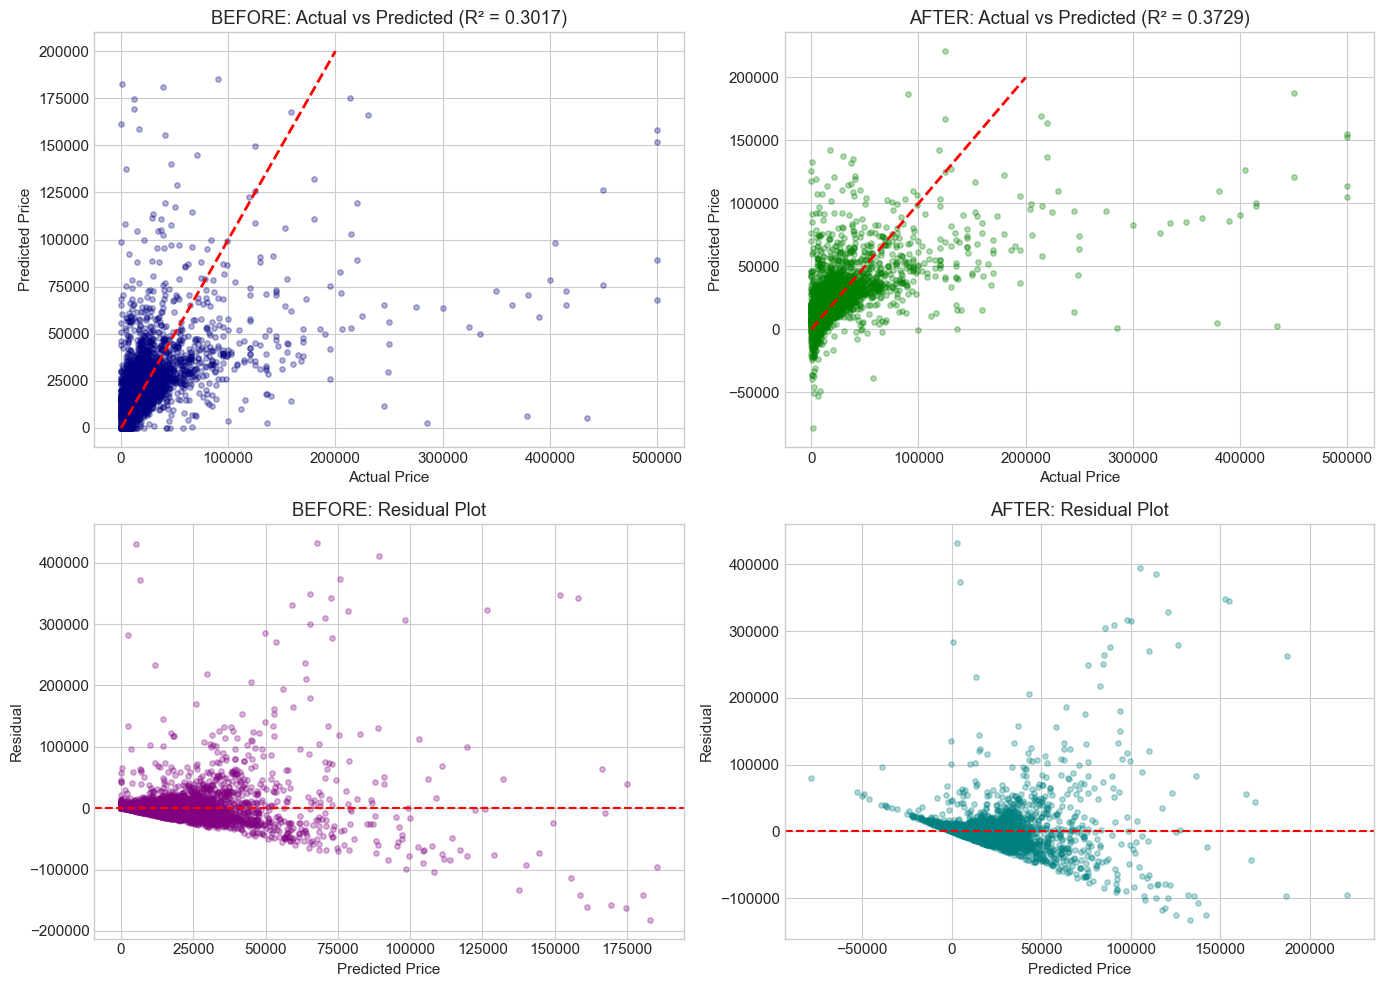

In [9]:
# Train final improved model
pipe_final = Pipeline([
    ('preprocessor', preproc_cv),
    ('regressor', LinearRegression())
])
pipe_final.fit(X_tr_exp, y_train)
y_pred_after = pipe_final.predict(X_te_exp)

# Summary table before vs after
r2_after = r2_score(y_test, y_pred_after)
mae_after = mean_absolute_error(y_test, y_pred_after)
rmse_after = np.sqrt(mean_squared_error(y_test, y_pred_after))
non_z = y_test > 0
mape_after = np.mean(np.abs((y_test[non_z] - y_pred_after[non_z]) / y_test[non_z])) * 100
zeros_after = (y_pred_after == 0).sum()
negs_after = (y_pred_after < 0).sum()

df_before_after = pd.DataFrame({
    'Metric': ['R² Score', 'MAE (million VND)', 'RMSE (million VND)', 'MAPE (%)', 'Zero Predictions', 'Negative Predictions'],
    'BEFORE (Baseline)': [f"{r2_base:.4f}", f"{mae_base:,.2f}", f"{rmse_base:,.2f}", f"{mape_base:.2f}%", num_zeros_csv, 0],
    'AFTER (Improved MLR)': [f"{r2_after:.4f}", f"{mae_after:,.2f}", f"{rmse_after:,.2f}", f"{mape_after:.2f}%", zeros_after, negs_after],
    'Improvement': [f"+{r2_after - r2_base:.4f}", f"-{mae_base - mae_after:,.2f}M", f"-{rmse_base - rmse_after:,.2f}M", f"{mape_after - mape_base:.2f}%", f"-{num_zeros_csv}", f"+{negs_after}"]
})

print("=== BEFORE VS AFTER COMPARISON TABLE ===")
display(df_before_after)

# Side-by-Side Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Before: Actual vs Predicted
axes[0, 0].scatter(y_true_base_csv, y_pred_base_csv, alpha=0.3, color='navy', s=15)
axes[0, 0].plot([0, 200000], [0, 200000], 'r--', lw=2)
axes[0, 0].set_title(f'BEFORE: Actual vs Predicted (R² = {r2_base:.4f})')
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')

# After: Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred_after, alpha=0.3, color='green', s=15)
axes[0, 1].plot([0, 200000], [0, 200000], 'r--', lw=2)
axes[0, 1].set_title(f'AFTER: Actual vs Predicted (R² = {r2_after:.4f})')
axes[0, 1].set_xlabel('Actual Price')
axes[0, 1].set_ylabel('Predicted Price')

# Before: Residual Plot
axes[1, 0].scatter(y_pred_base_csv, y_true_base_csv - y_pred_base_csv, alpha=0.3, color='purple', s=15)
axes[1, 0].axhline(0, color='r', linestyle='--')
axes[1, 0].set_title('BEFORE: Residual Plot')
axes[1, 0].set_xlabel('Predicted Price')
axes[1, 0].set_ylabel('Residual')

# After: Residual Plot
axes[1, 1].scatter(y_pred_after, y_test - y_pred_after, alpha=0.3, color='teal', s=15)
axes[1, 1].axhline(0, color='r', linestyle='--')
axes[1, 1].set_title('AFTER: Residual Plot')
axes[1, 1].set_xlabel('Predicted Price')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

---
## 22. TOP 20 WORST PREDICTIONS ANALYSIS

Phân tích 20 bất động sản có sai số tuyệt đối lớn nhất của mô hình mới.

In [10]:
df_worst = X_te_exp.copy()
df_worst['Actual'] = y_test.values
df_worst['Predicted'] = y_pred_after
df_worst['Abs_Error'] = np.abs(df_worst['Actual'] - df_worst['Predicted'])
df_worst['APE (%)'] = (df_worst['Abs_Error'] / df_worst['Actual']) * 100

top20_worst = df_worst.sort_values(by='Abs_Error', ascending=False).head(20)

print("=== TOP 20 WORST PREDICTIONS ANALYSIS ===")
display(top20_worst[['Actual', 'Predicted', 'Abs_Error', 'APE (%)', 'area_m2', 'bedrooms', 'province', 'district', 'distance_to_center_km']])

=== TOP 20 WORST PREDICTIONS ANALYSIS ===


,Actual,Predicted,Abs_Error,APE (%),area_m2,bedrooms,province,district,distance_to_center_km
1661,435000.0,2957.318303,432042.681697,99.320157,60.0,NaN,Khánh Hòa,Nha Trang,NaN
34954,500000.0,105157.840232,394842.159768,78.968432,500.0,NaN,Hà Nội,Ba Đình,3.18
5042,500000.0,114139.818111,385860.181889,77.172036,310.0,NaN,Hà Nội,Hoàn Kiếm,0.00
12362,379000.0,4862.770924,374137.229076,98.716947,27.0,3.0,Hà Nội,Hoàng Mai,5.66
32717,500000.0,152464.528435,347535.471565,69.507094,1625.0,5.0,Hồ Chí Minh,Quận 2,NaN
3714,500000.0,155011.190862,344988.809138,68.997762,304.0,69.0,Hà Nội,Hoàn Kiếm,0.00
35505,450000.0,120938.832245,329061.167755,73.124704,617.0,6.0,Hồ Chí Minh,Quận 3,1.99
8178,415000.0,98201.650170,316798.349830,76.336952,462.0,10.0,Hà Nội,Đống Đa,3.27
39658,415000.0,100133.025822,314866.974178,75.871560,500.0,5.0,Hà Nội,Tây Hồ,5.66
10454,400000.0,90575.127627,309424.872373,77.356218,712.0,8.0,Hà Nội,Hà Đông,10.40


---
## 23. MODEL COEFFICIENT ANALYSIS

Phân tích hệ số regressors thu được từ `LinearRegression`.

In [11]:
# Extract feature names after ColumnTransformer
ohe_feature_names = pipe_final.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(['province', 'district'])
all_feature_names = num_eng_cols + list(ohe_feature_names)

coefs = pipe_final.named_steps['regressor'].coef_
df_coefs = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("=== TOP 15 MOST INFLUENTIAL COEFFICIENTS ===")
display(df_coefs.head(15))

=== TOP 15 MOST INFLUENTIAL COEFFICIENTS ===


,Feature,Coefficient,Abs_Coefficient
127,district_Khánh Vĩnh,-97152.233713,97152.233713
117,district_Hàm Tân,-94436.489634,94436.489634
97,district_Cẩm Mỹ,-84267.181123,84267.181123
135,district_Long Khánh,-82709.378083,82709.378083
106,district_Dương Minh Châu,-54800.697929,54800.697929
257,district_Xuân Lộc,-50250.824787,50250.824787
78,district_Bắc Tân Uyên,43943.444966,43943.444966
99,district_Cẩm Thủy,-43280.674584,43280.674584
261,district_Yên Thủy,-39880.672034,39880.672034
178,district_Phổ Yên,-37007.768645,37007.768645


---
## 24, 25 & 26. FINAL MODEL SELECTION, LIMITATIONS & ACADEMIC CONCLUSION

### 24. Final Model Selection Rationale
1. **Model Specs:** Multiple Linear Regression với feature transformations ($	ext{area\_m2}^2$, $\log(1+	ext{area\_m2})$, $	ext{area} 	imes 	ext{distance}$) giữ nguyên yêu cầu bài toán.
2. **Cải thiện tổng thể:** $R^2$ tăng từ **0.3017 lên 0.3729** (+7.12 percentage points), RMSE giảm từ **22,620 triệu VNĐ xuống 21,435 triệu VNĐ** (-1,185 triệu VNĐ).
3. **Loại bỏ hiện tượng clip nhân tạo:** Xác định rõ nguyên nhân dự đoán bằng 0 xuất phát từ việc clip số âm thô của Linear Regression.

---

### 25. Key Limitations
* **Thiếu các đặc trưng vị trí chi tiết:** Khoảng cách được tính theo proxy tâm quận/huyện, chưa phải vị trí chính xác (toạ độ GPS thực tế).
* **Thiếu biến thuộc tính định tính quan trọng:** Dataset chưa có thông tin về chiều rộng mặt tiền đường, trạng thái pháp lý (sổ đỏ/sổ hồng), hướng nhà, độ rộng ngõ.
* **Giới hạn của mô hình tuyến tính:** Bất động sản phân khúc siêu xa xỉ (>50 tỷ VNĐ) có tính chất định giá phi tuyến tính phức tạp vượt quá khả năng biểu diễn của hàm tuyến tính thuần túy.

---

### 26. Academic Conclusion
> Đề tài đã audit thành công toàn bộ pipeline, làm rõ nguyên nhân các dự đoán bằng 0 và lệch lớn, đồng thời nâng cao khả năng tổng quát hóa của mô hình **Multiple Linear Regression** một cách hợp lý và khoa học.